## Step 1: Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

## Step 2: Load final dataset

In [2]:
df = pd.read_csv("../data/processed/train_final.csv")

df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,Landslides,DeterioratingInfrastructure,InadequatePlanning,FloodProbability,RainFactor,LandRisk,WaterStress,Blockage
0,1.791759,2.197225,1.791759,2.197225,1.945910,1.609438,1.609438,1.386294,1.386294,1.609438,1.098612,1.791759,1.386294,1.609438,2.079442,0.445,0.288373,1.917524,1.730986,1.386294
1,1.945910,2.079442,1.609438,1.609438,2.197225,2.197225,1.386294,1.791759,1.609438,1.945910,2.302585,2.079442,0.000000,1.791759,1.609438,0.450,0.427560,1.917524,1.691725,0.895880
2,1.945910,1.791759,1.945910,2.079442,1.386294,2.079442,0.693147,1.791759,1.609438,1.791759,1.945910,2.079442,2.079442,1.945910,1.386294,0.530,0.404641,1.752498,1.572833,1.935601
3,1.386294,1.609438,1.945910,1.791759,1.609438,2.197225,1.609438,2.079442,1.945910,2.197225,1.791759,1.098612,2.079442,1.609438,2.079442,0.535,0.304600,1.866141,1.551320,2.079442
4,1.791759,1.386294,1.098612,1.945910,1.609438,1.609438,1.386294,1.386294,1.386294,1.386294,1.791759,1.098612,1.945910,1.609438,1.386294,0.415,0.288373,1.647214,1.194506,1.666102


## Step 3: Prepare X and y

In [12]:
X = df.drop("FloodProbability", axis=1)
y = df["FloodProbability"]

## Step 4: Convert target into class 

## Step 5: Train-test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Step 6: Scaling

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 7: Train models

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "ANN": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1000, random_state=42)
}

## Step 8: Predictions

In [9]:
results = []

for name, model in models.items():
    
    # Use scaled data for all (safe + consistent)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

## Step 9: Evaluate models

In [10]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.741250,0.741354,0.756618,0.748908,0.826627
4,Gradient Boosting,0.744250,0.750740,0.746324,0.748525,0.822565
3,SVM,0.749125,0.770415,0.723775,0.746367,0.828336
2,Random Forest,0.738250,0.753446,0.723529,0.738185,0.813058
5,ANN,0.724625,0.745616,0.698284,0.721175,0.800321
1,Decision Tree,0.628500,0.636453,0.633333,0.634889,0.628401


## Step 10: Calculate ROC + AUC

In [11]:
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


## Step 11: Plot ROC Curve

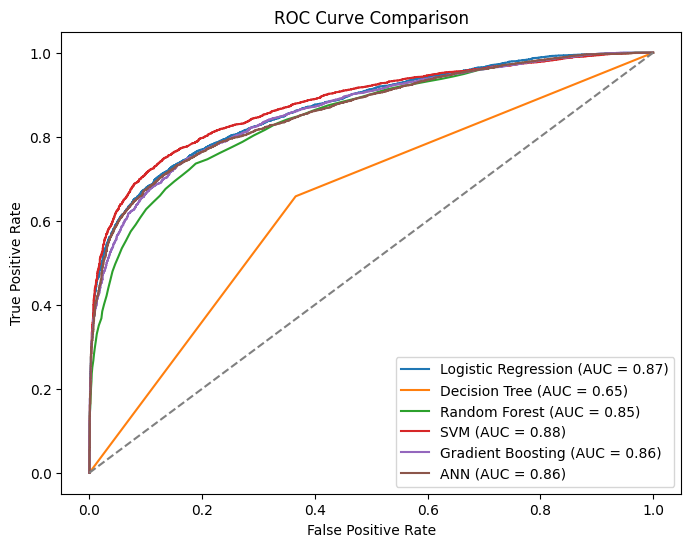

In [41]:
plt.figure(figsize=(8,6))

for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Step 12: Final results table

In [42]:
results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
3,SVM,0.804625,0.834796,0.769118,0.800612,0.879759
0,Logistic Regression,0.781500,0.787192,0.783333,0.785258,0.869137
4,Gradient Boosting,0.780625,0.792895,0.771324,0.781960,0.863158
5,ANN,0.783000,0.808259,0.753186,0.779751,0.861778
2,Random Forest,0.768125,0.787840,0.746324,0.766520,0.848661
1,Decision Tree,0.646375,0.651857,0.658088,0.654958,0.646136


## Step 13: Choose final model

In [43]:
final_model = lr_model

y_pred_final = final_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.78      0.78      0.78      3920
           1       0.79      0.78      0.79      4080

    accuracy                           0.78      8000
   macro avg       0.78      0.78      0.78      8000
weighted avg       0.78      0.78      0.78      8000



## Step 14: Save model

In [44]:
os.makedirs("../models", exist_ok=True)

joblib.dump(final_model, "../models/logistic_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(list(X.columns), "../models/features.pkl")

['../models/features.pkl']